# LAB 4. Задача 1. Статистика файлів по місяцях

**Виконавець:** Сєров Едуард Олегович, група **К-26**  
**Викладач:** Ляшко А. В.  
**Варіант:** 90 (з lab2)

**Умова задачі:** За даними задачі 2 ЛР№1 для кожного місяця побудувати 16 графіків на одному зображенні (для реальних даних та для штучних). Побудувати кругову діаграму.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
print(f'numpy {np.__version__}, pandas {pd.__version__}, matplotlib {matplotlib.__version__}')

numpy 2.4.1, pandas 3.0.0, matplotlib 3.10.8


In [2]:
CODE_LIST = {'.cpp', '.hpp', '.c', '.h', '.py', '.pyw', '.cs', '.js', '.java'}
WHITE_LIST = CODE_LIST | {'.html', '.json', '.txt', '.ipynb'}

def kind(ext):
    if ext in CODE_LIST: return 'C'
    elif ext in WHITE_LIST: return 'W'
    else: return 'O'

In [3]:
def prepare_monthly(data):
    data = data.copy()
    data.fillna(value={'ext': ''}, inplace=True)
    data['kind'] = data['ext'].apply(kind)
    sel = data[data['kind'] != 'O'].copy()
    grp = sel[['year', 'mon', 'cnt', 'size', 'lines']].groupby(['year', 'mon'])
    res = grp.agg({'cnt': 'sum', 'size': ['sum', 'mean'], 'lines': ['sum', 'mean']})
    res.columns = res.columns.to_flat_index()
    res.columns = ['Кількість', 'Сумарний розмір', 'Середній розмір',
                   'Кількість рядків', 'Середня кількість рядків']
    res['Сумарний розмір'] = (res['Сумарний розмір'] / 1024).round().astype(int)
    res.fillna(value={'Середня кількість рядків': 0, 'Кількість рядків': 0}, inplace=True)
    res['Середній розмір'] = res['Середній розмір'].round().astype(int)
    res['Середня кількість рядків'] = res['Середня кількість рядків'].round().astype(int)
    res['Кількість рядків'] = res['Кількість рядків'].astype(int)
    res.sort_index(ascending=[True, True], inplace=True)
    return res

### Функція побудови графіків

In [4]:
def make_16_plots(res, title_prefix, outfile):
    month_ua = {1:'Січ',2:'Лют',3:'Бер',4:'Кві',5:'Тра',6:'Чер',
                7:'Лип',8:'Сер',9:'Вер',10:'Жов',11:'Лис',12:'Гру'}
    labels = [f"{month_ua[m]}\n{y}" for y, m in res.index]
    char_cols = ['Кількість', 'Сумарний розмір', 'Кількість рядків', 'Середній розмір']
    colors = ['#1565C0', '#C62828', '#2E7D32', '#6A1B9A']

    fig, axes = plt.subplots(4, 4, figsize=(20, 16))
    fig.suptitle(f'Сєров Едуард, К-26 | ЛР№4 | Задача 1 | {title_prefix}\n'
                 'Статистика файлів з білого списку по місяцях',
                 fontsize=13, fontweight='bold', y=0.98)

    for ci, (col_name, color) in enumerate(zip(char_cols, colors)):
        vals = res[col_name].values.astype(float)
        s_vals = pd.Series(vals, index=labels)
        s_cum  = s_vals.cumsum()

        s_vals.plot(ax=axes[0, ci], marker='o', color=color, linewidth=2, markersize=5)
        axes[0, ci].set_title(col_name, fontsize=9)
        axes[0, ci].set_xticks(range(len(labels))); axes[0, ci].set_xticklabels(labels, fontsize=7)
        axes[0, ci].grid(True, alpha=0.3)

        s_cum.plot(ax=axes[1, ci], marker='s', color=color, linewidth=2, linestyle='--')
        axes[1, ci].fill_between(range(len(labels)), s_cum.values, alpha=0.18, color=color)
        axes[1, ci].set_title(f'{col_name} (накоп.)', fontsize=9)
        axes[1, ci].set_xticks(range(len(labels))); axes[1, ci].set_xticklabels(labels, fontsize=7)
        axes[1, ci].grid(True, alpha=0.3)

        s_vals.plot(kind='bar', ax=axes[2, ci], color=color, alpha=0.85, edgecolor='white')
        axes[2, ci].set_title(col_name, fontsize=9)
        axes[2, ci].set_xticklabels(labels, fontsize=7, rotation=0)
        axes[2, ci].grid(True, alpha=0.3, axis='y')

        df_stack = pd.DataFrame({m: [v] for m, v in zip(labels, vals)}, index=[col_name])
        df_stack.T.plot(kind='bar', stacked=True, ax=axes[3, ci],
                        color=color, alpha=0.85, edgecolor='white', legend=False)
        axes[3, ci].set_title(f'{col_name} (накоп. bar)', fontsize=9)
        axes[3, ci].set_xticklabels(labels, fontsize=7, rotation=0)
        axes[3, ci].grid(True, alpha=0.3, axis='y')

    for row, label in enumerate(['Графік', 'Графік з накоп.', 'Стовпч. діаграма', 'Стовпч. з накоп.']):
        axes[row, 0].set_ylabel(label, fontsize=9)

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.savefig(outfile, dpi=130, bbox_inches='tight')
    plt.show()

### Реальні дані

In [5]:
real_data = pd.read_csv('lab1_1.csv', encoding='utf-8', header=0, dtype={'lines': 'Int64'})
res_real = prepare_monthly(real_data)
print(f'Місяців у реальних даних: {len(res_real)}')
res_real

Місяців у реальних даних: 6


Кількість  Сумарний розмір  Середній розмір  Кількість рядків  \
year mon                                                                  
2025 4            3                1              996                 0   
     10         133              325           166220              4491   
     11          71             1111           227533             14873   
     12          13               10             2086               167   
2026 1        27543           191849         39290726           3557450   
     2          106            10489          2685184              1228   

          Середня кількість рядків  
year mon                            
2025 4                           0  
     10                       4491  
     11                       7436  
     12                         84  
2026 1                     1778725  
     2                        1228

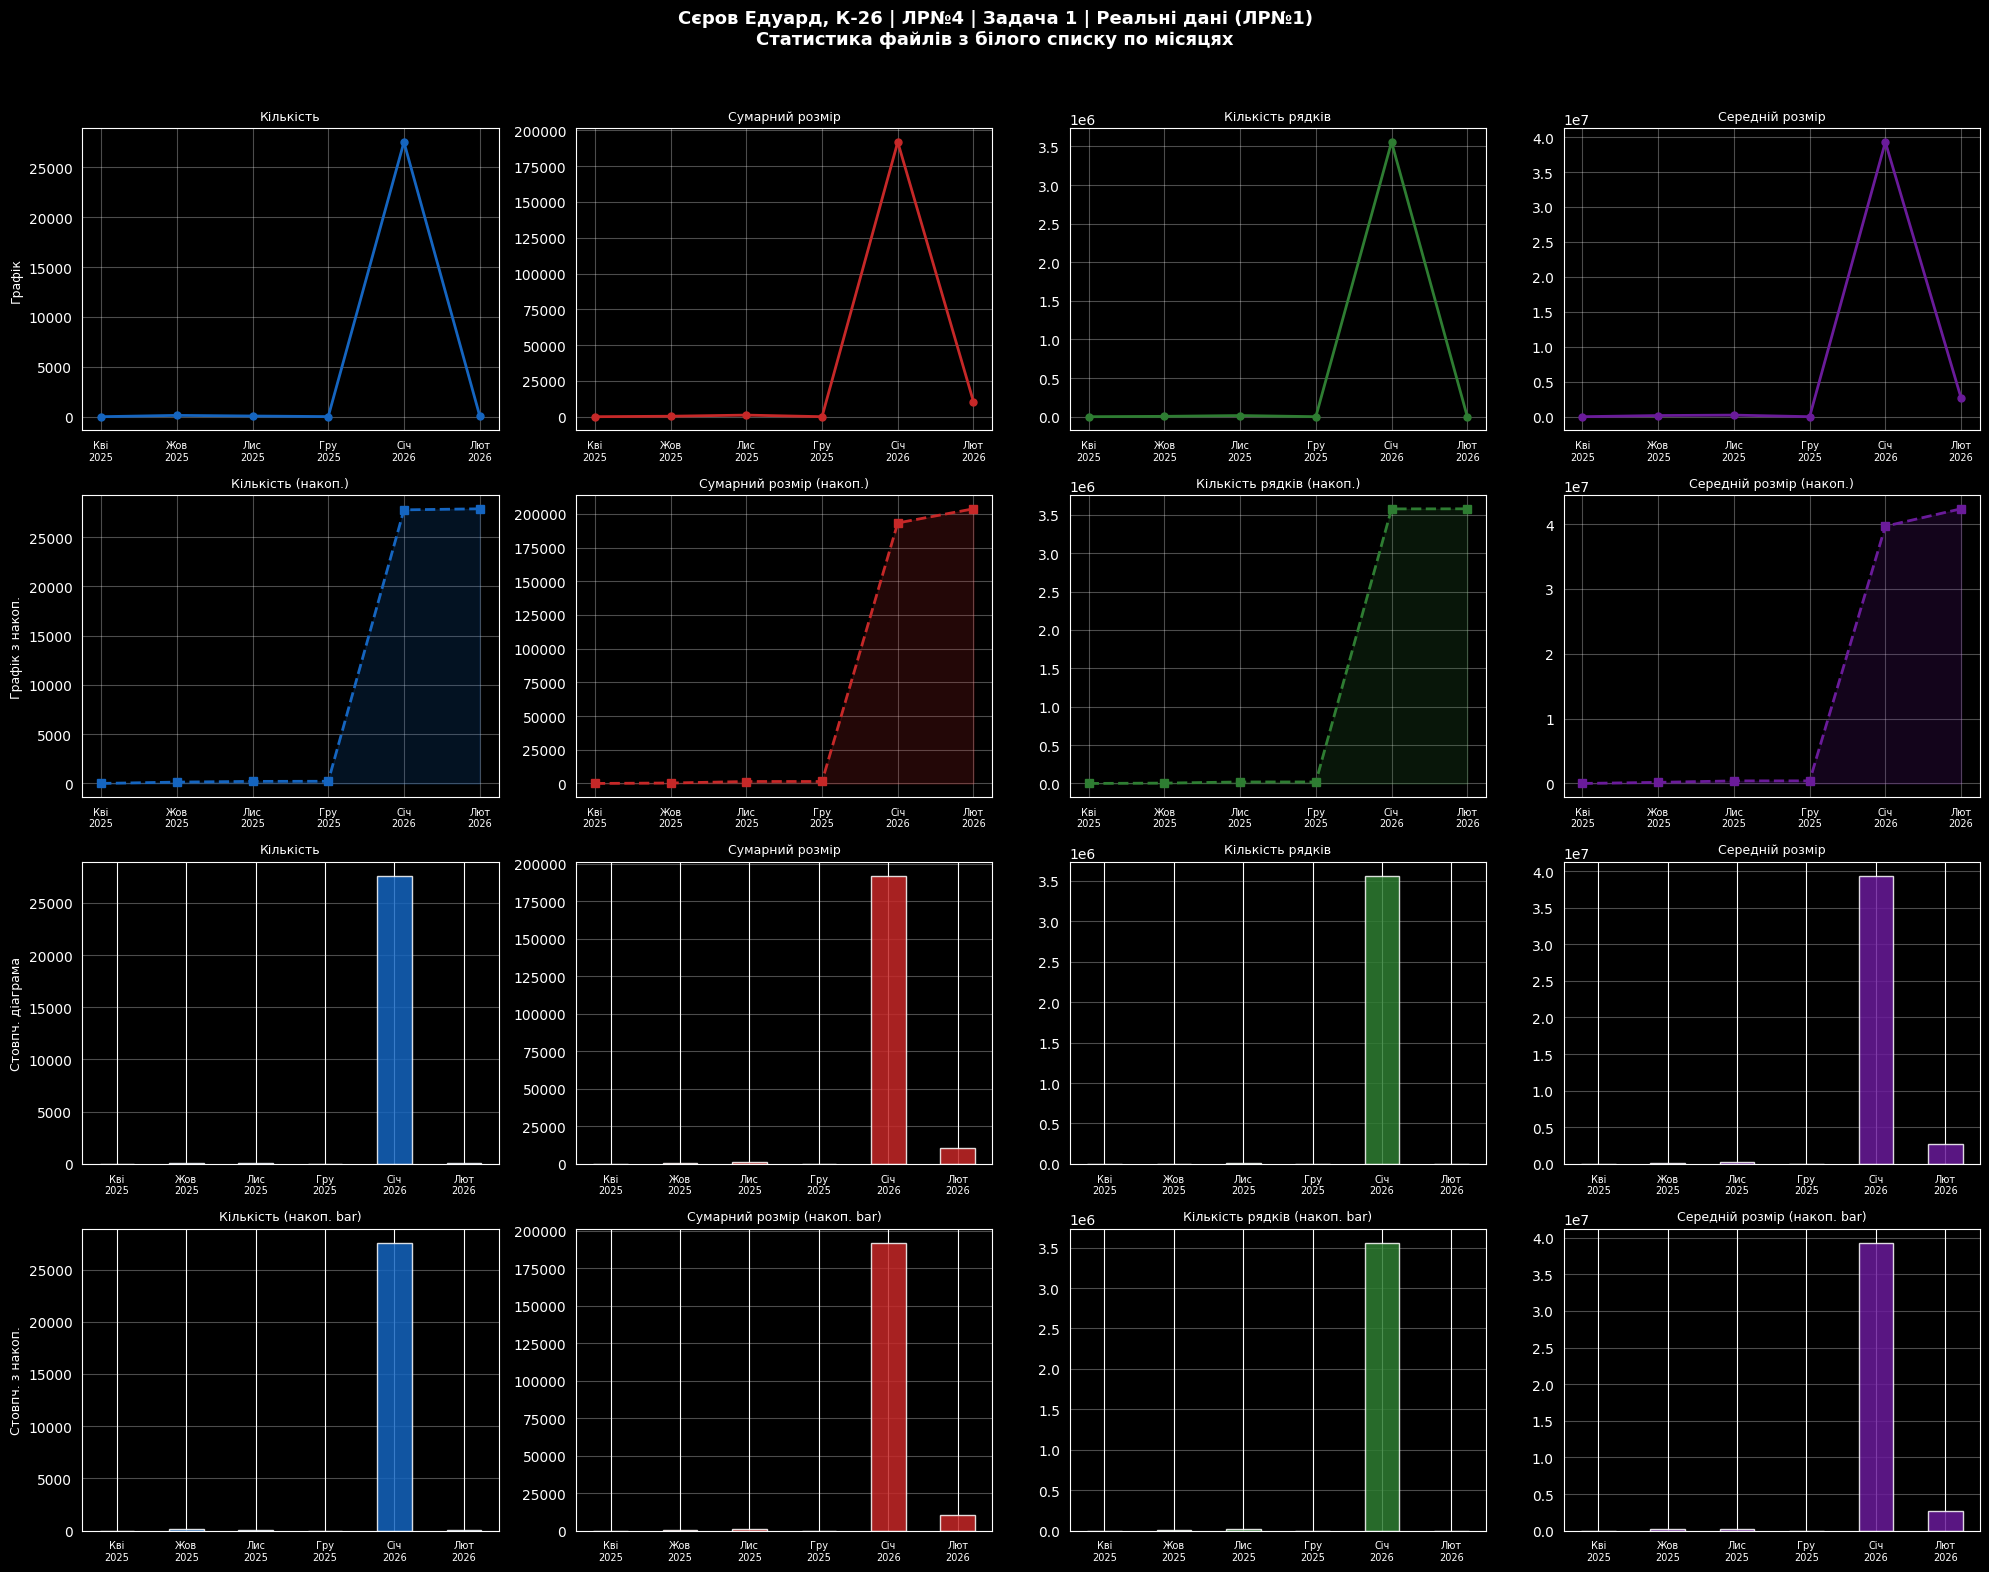

In [6]:
make_16_plots(res_real, 'Реальні дані (ЛР№1)', 'task1_real.png')

### Штучні дані

In [7]:
np.random.seed(7)
months_art = [(2024, 6), (2024, 7), (2024, 8), (2024, 9), (2024, 10),
              (2024, 11), (2024, 12), (2025, 1), (2025, 2), (2025, 3)]
rows_art = []
for year, mon in months_art:
    for ext in sorted(WHITE_LIST):
        cnt  = np.random.randint(5, 60)
        size = cnt * np.random.randint(500, 10000)
        lines = cnt * np.random.randint(20, 250) if ext in CODE_LIST else None
        rows_art.append({'year': year, 'mon': mon, 'ext': ext,
                         'cnt': cnt, 'size': size, 'lines': lines})
    for ext in ['.psd', '.xlsx', '.pdf', '.md', '.docx']:
        rows_art.append({'year': year, 'mon': mon, 'ext': ext,
                         'cnt': np.random.randint(1, 15),
                         'size': np.random.randint(3000, 80000), 'lines': None})

art_data = pd.DataFrame(rows_art)
res_art = prepare_monthly(art_data)
print(f'Місяців у штучних даних: {len(res_art)}')
res_art

Місяців у штучних даних: 10


Кількість  Сумарний розмір  Середній розмір  Кількість рядків  \
year mon                                                                  
2024 6          417             2502           197092             39653   
     7          335             1652           130117             42663   
     8          389             2116           166639             35552   
     9          471             2546           200532             64454   
     10         473             2358           185766             37845   
     11         410             2494           196447             33685   
     12         389             2374           187008             30769   
2025 1          384             2426           191062             44925   
     2          376             1983           156189             44795   
     3          419             2011           158374             43421   

          Середня кількість рядків  
year mon                            
2024 6                        4406  
     7                        4740  
     8                        3950  
     9                        7162  
     10                       4205  
     11                       3743  
     12                       3419  
2025 1                        4992  
     2                        4977  
     3                        4825

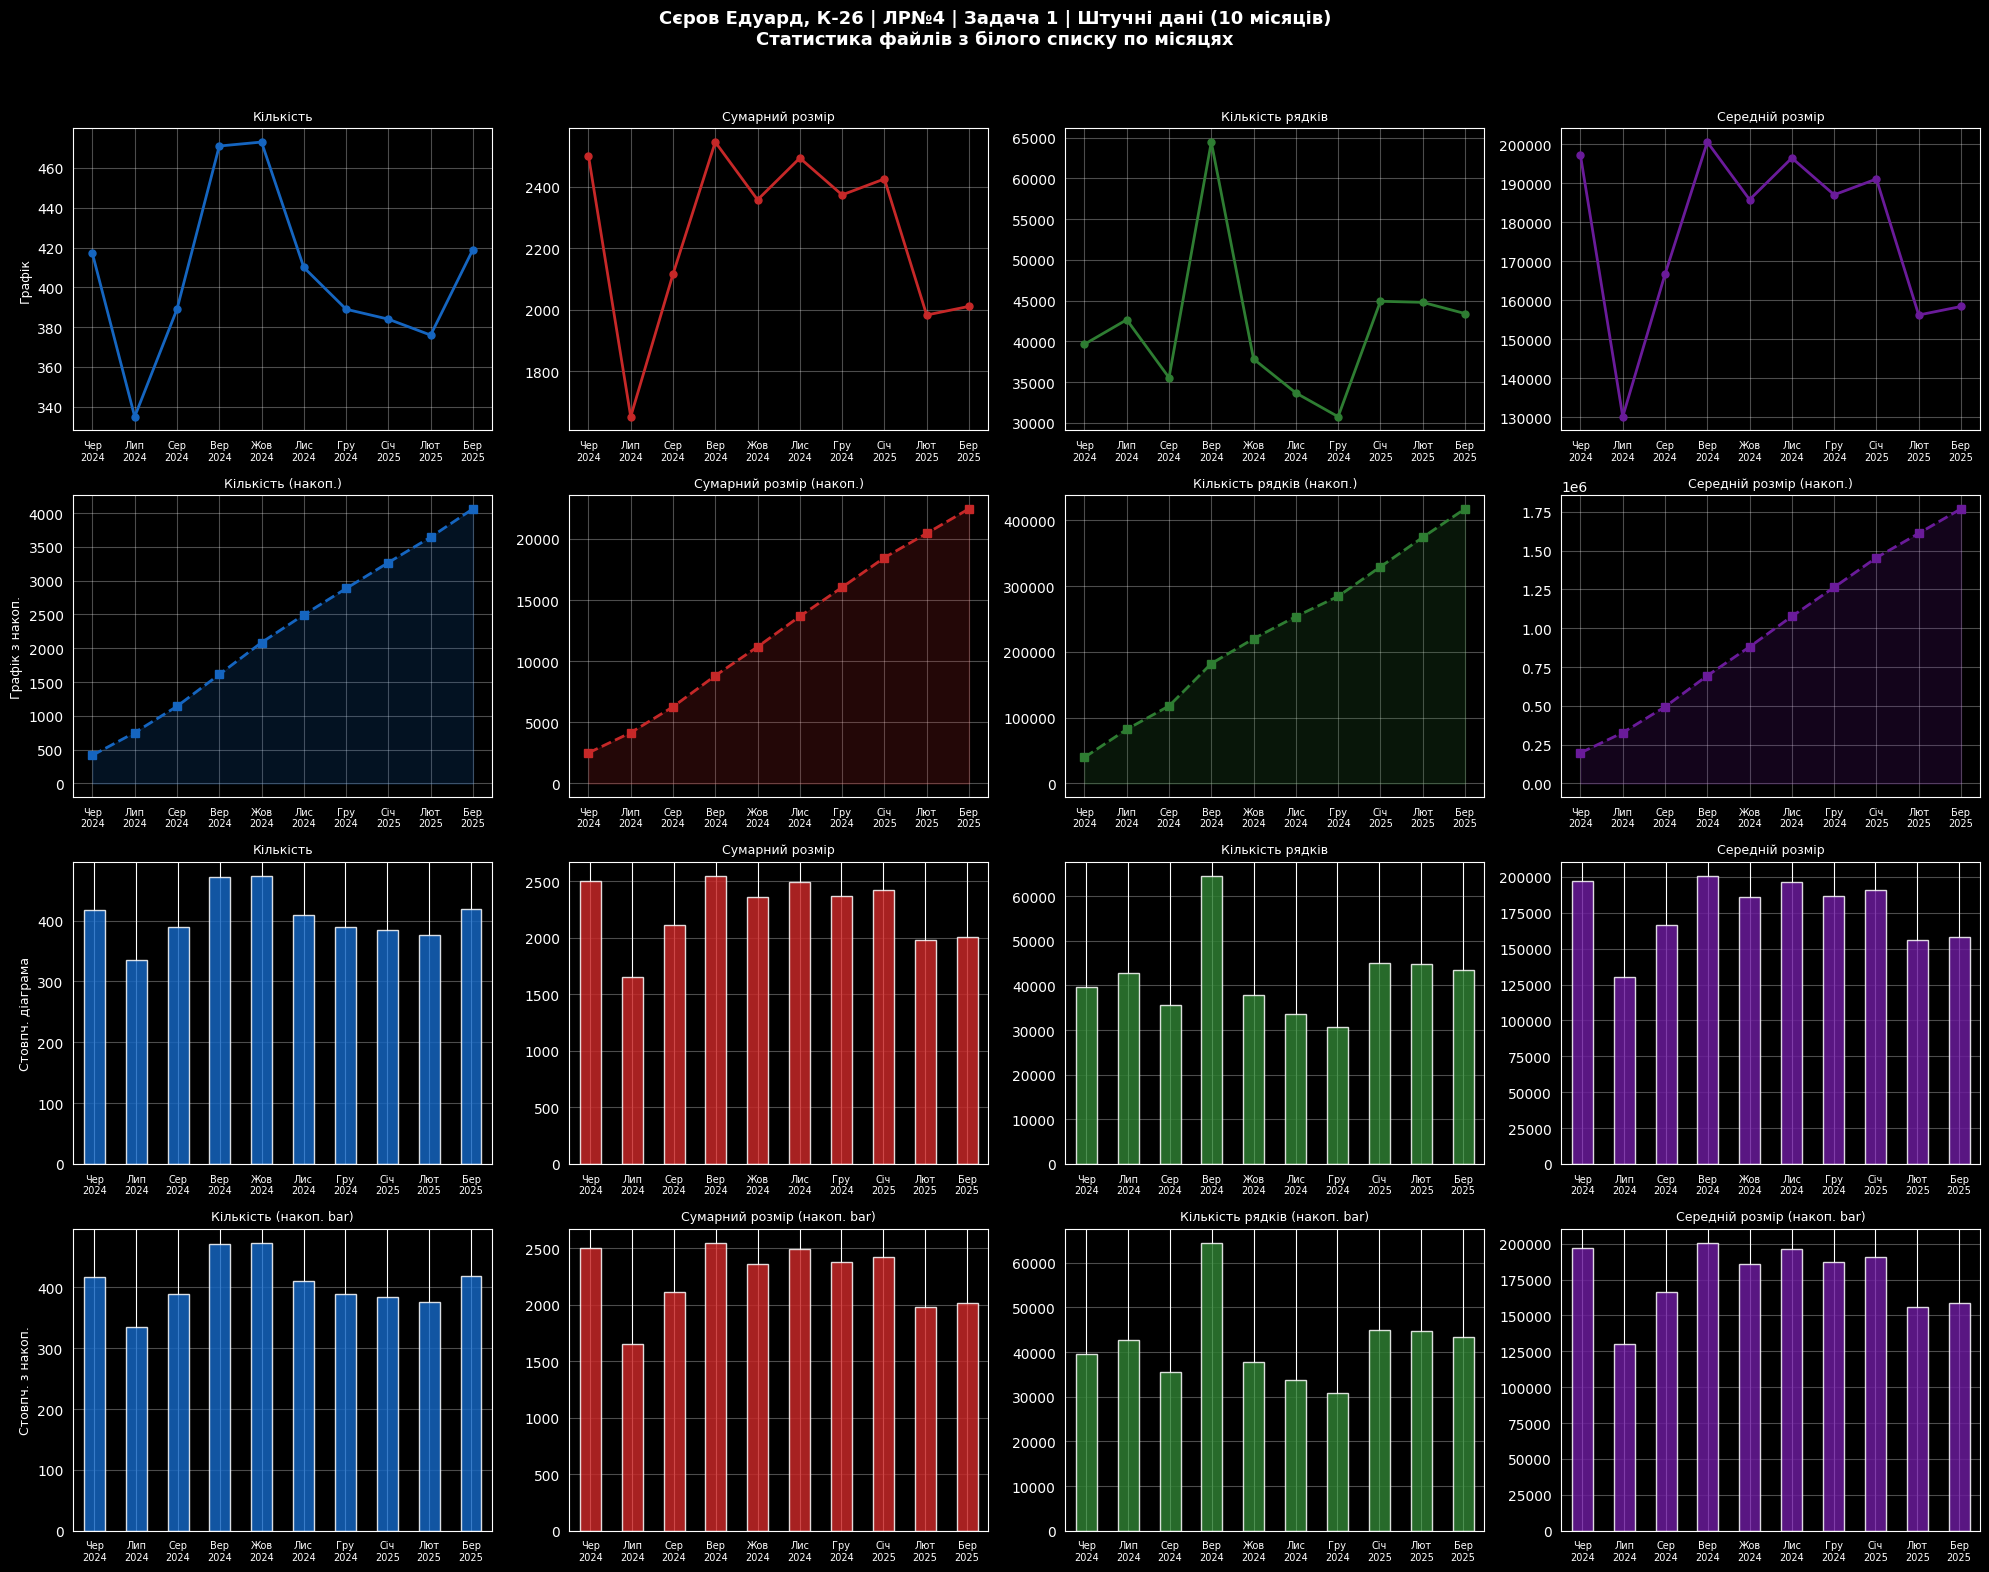

In [8]:
make_16_plots(res_art, 'Штучні дані (10 місяців)', 'task1_artificial.png')

### Кругова діаграма (к-сть файлів за розширенням, реальні дані)

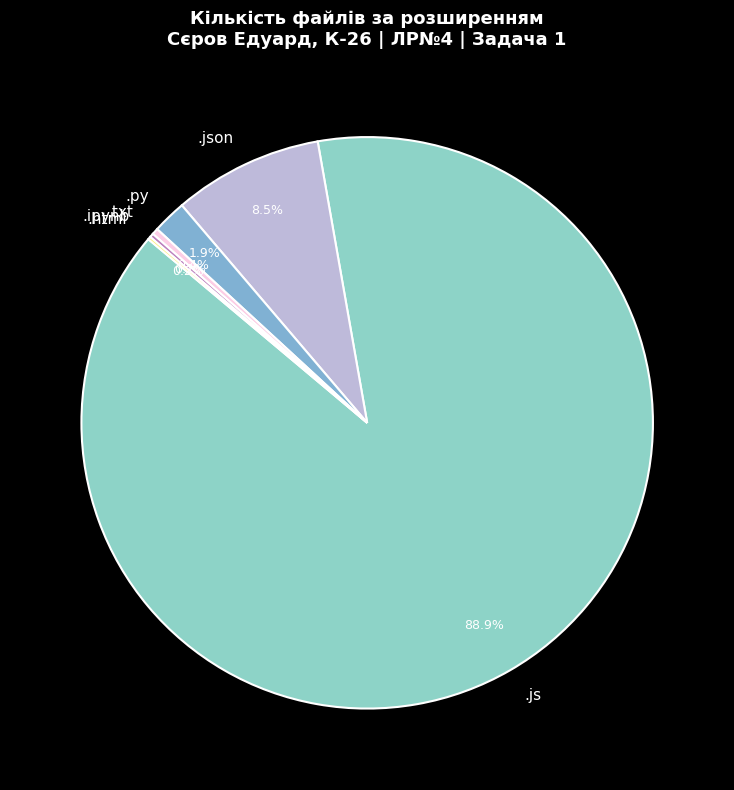

In [9]:
task1_g = real_data.copy()
task1_g.fillna(value={'ext': ''}, inplace=True)
task1_g['kind'] = task1_g['ext'].apply(kind)
task1_cnt = task1_g[task1_g['kind'] != 'O'][['ext','cnt']].groupby('ext').sum()
task1_cnt.sort_values('cnt', ascending=False, inplace=True)

top = task1_cnt.head(9)
other_val = task1_cnt['cnt'].sum() - top['cnt'].sum()
if other_val > 0:
    top = pd.concat([top, pd.DataFrame({'cnt': [other_val]}, index=['інші'])])

fig2, ax = plt.subplots(figsize=(10, 8))
wedge_colors = plt.cm.Set3(np.linspace(0, 1, len(top)))
wedges, texts, autotexts = ax.pie(
    top['cnt'], labels=top.index, autopct='%1.1f%%',
    colors=wedge_colors, startangle=140,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}, pctdistance=0.82)
for t in texts: t.set_fontsize(11)
for at in autotexts: at.set_fontsize(9)
ax.set_title('Кількість файлів за розширенням\nСєров Едуард, К-26 | ЛР№4 | Задача 1',
             fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('task1_pie.png', dpi=150, bbox_inches='tight')
plt.show()